Email Spam Detection with Machine Learning 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
%pip install nltk
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Download NLTK stopwords (only needs to be run once)
nltk.download('stopwords')
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Load the dataset (using latin-1 encoding to prevent errors)
df = pd.read_csv('spam.csv', encoding='latin-1')

# The dataset has 3 extra empty columns ('Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'). Let's drop them.
df = df[['v1', 'v2']]

# Rename columns for better readability
df.columns = ['label', 'message']

# Map labels to binary values for the machine learning models (spam = 1, ham = 0)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

display(df.head())

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


--- Class Distribution ---
Ham:  4825 (86.59%)
Spam: 747 (13.41%)



C:\Users\Admin\AppData\Local\Temp\ipykernel_12644\3727575489.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


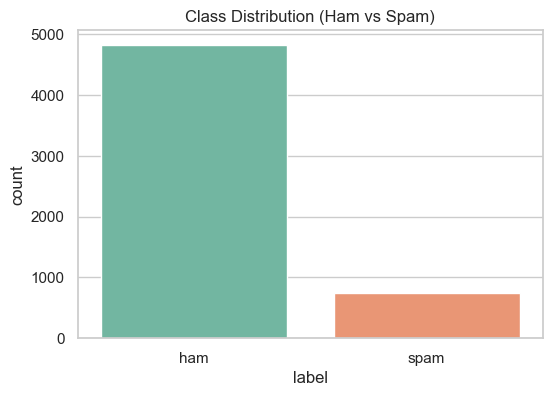

In [6]:
# 1. Print counts and percentages
class_counts = df['label'].value_counts()
class_percentages = df['label'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(f"Ham:  {class_counts['ham']} ({class_percentages['ham']:.2f}%)")
print(f"Spam: {class_counts['spam']} ({class_percentages['spam']:.2f}%)\n")

# 2. Visualize distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Class Distribution (Ham vs Spam)')
plt.show()

In [8]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase conversion
    text = text.lower()
    # 2. Remove punctuation and numbers using regex
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Stopword removal
    words = text.split()
    clean_words = [word for word in words if word not in stop_words]
    
    return ' '.join(clean_words)

# Apply the pipeline to create a new cleaned column
df['clean_message'] = df['message'].apply(preprocess_text)

print("Text before and after preprocessing:")
display(df[['message', 'clean_message']].head())

Text before and after preprocessing:


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


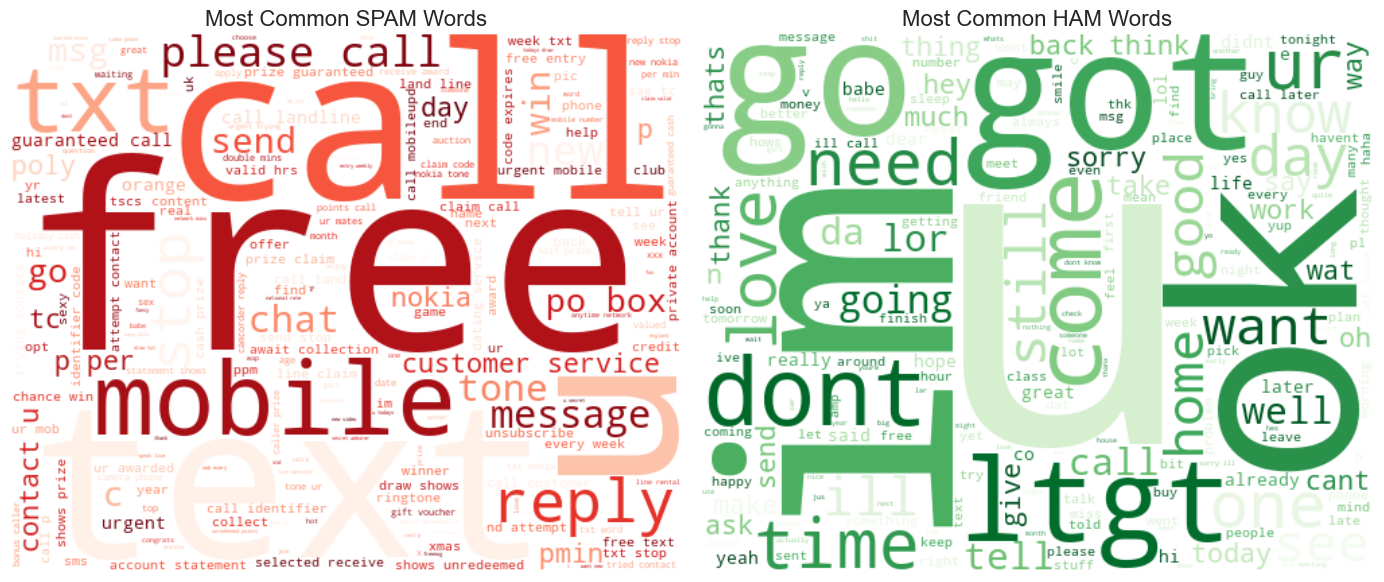

In [9]:
# Extract all words for both categories
spam_words = ' '.join(list(df[df['label'] == 'spam']['clean_message']))
ham_words = ' '.join(list(df[df['label'] == 'ham']['clean_message']))

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spam WordCloud
wc_spam = WordCloud(width=500, height=400, background_color='white', colormap='Reds').generate(spam_words)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common SPAM Words', fontsize=16)

# Ham WordCloud
wc_ham = WordCloud(width=500, height=400, background_color='white', colormap='Greens').generate(ham_words)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common HAM Words', fontsize=16)

plt.tight_layout()
plt.show()

TF-IDF EXPLANATION

### Feature Extraction using TF-IDF Vectorizer
Machine learning algorithms cannot read raw text; they require numerical input. We use **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert our text into numbers.

*   **Term Frequency (TF):** Measures how frequently a word appears in a specific email. If a word appears many times, it gets a higher score.
*   **Inverse Document Frequency (IDF):** Measures how rare or common a word is across *all* emails. Words that appear in almost every email (like "ok", "call") get penalized, while rare words get boosted.

**In short:** TF-IDF highlights words that are frequent in a specific message but rare across the entire dataset, making them highly distinctive "features" for our classifier to learn from.

In [10]:
# 1. Initialize TF-IDF Vectorizer
# max_features=3000 limits the vocabulary to the top 3000 words to speed up training
tfidf = TfidfVectorizer(max_features=3000)

# 2. Extract features (X) and target labels (y)
X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['label_num'].values

# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4457, 3000)
Testing data shape: (1115, 3000)


========== Multinomial Naive Bayes ==========
Accuracy:  0.9704
Precision: 0.9915
Recall:    0.7852
F1-Score:  0.8764



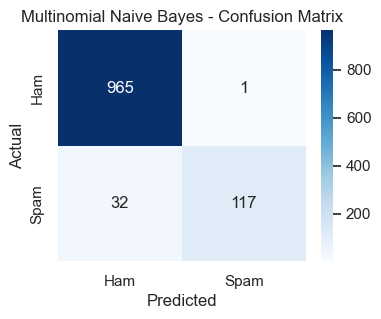

========== Logistic Regression ==========
Accuracy:  0.9614
Precision: 0.9818
Recall:    0.7248
F1-Score:  0.8340



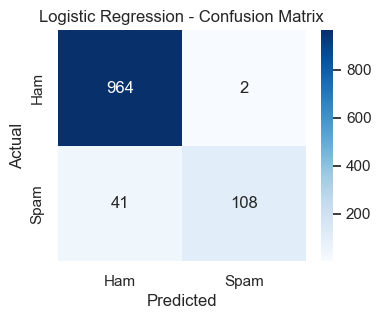

In [11]:
# Initialize models
nb_model = MultinomialNB()
lr_model = LogisticRegression(random_state=42)

# Train models
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# Generate Predictions
nb_preds = nb_model.predict(X_test)
lr_preds = lr_model.predict(X_test)

# Custom evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"========== {name} ==========")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}\n")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Evaluate both
evaluate_model("Multinomial Naive Bayes", y_test, nb_preds)
evaluate_model("Logistic Regression", y_test, lr_preds)

### Discussion: Why is Recall particularly important for Spam Detection?

In spam detection, evaluating a model requires balancing **Precision** (avoiding false positives) and **Recall** (avoiding false negatives). 

*   **Precision:** Out of all emails flagged as spam, how many were *actually* spam? (A false positive means a legitimate email was sent to the spam folder).
*   **Recall:** Out of all actual spam emails, how many did we successfully catch? (A false negative means a spam email slipped through to the inbox).

While high precision is critical so users don't miss important legitimate emails, **Recall** is a vital metric to watch. If a spam filter has low recall, it fails at its primary job: cleaning the inbox. Users will be flooded with malicious phishing attempts, scams, and junk mail. A robust spam classifier must strike a balance—achieving a high recall to catch the vast majority of spam, while maintaining near-perfect precision to protect legitimate communications.